In [1]:
import pandas as pd
import os

os.chdir(r"C:\Users\joyde\Documents\Learnings\Projects\Budgeting\Budget_Python")
os.getcwd()

'C:\\Users\\joyde\\Documents\\Learnings\\Projects\\Budgeting\\Budget_Python'

In [2]:
file_name = "Budgeting_Project.xlsx"

In [3]:
actual_df = pd.read_excel(file_name, sheet_name="Actuals", usecols="B:G", skiprows=2, nrows=10)
budget_df = pd.read_excel(file_name, sheet_name="Forecasted Budget", usecols="B:G", skiprows=2, nrows=10)

actual_df

,Particulars,2026-03-31 00:00:00,2026-06-30 00:00:00,2026-09-30 00:00:00,2026-12-31 00:00:00,FY 2026
0,Revenue,185000.000000,212750.000000,244662.500000,282587.500000,925000.000000
1,COGS,51340.476190,59041.547619,67897.779762,78422.577381,256702.380952
2,Gross Profit,133659.523810,153708.452381,176764.720238,204164.922619,668297.619048
3,Employee Expenses,8750.000000,8787.500000,9014.750000,8447.750000,35000.000000
4,Factory & Equipments,5500.000000,5517.500000,5623.550000,5358.950000,22000.000000
5,Depreciation Expenses,1250.000000,1250.000000,1250.000000,1250.000000,5000.000000
6,Other Expenses,500.000000,505.000000,535.300000,459.700000,2000.000000
7,EBT,117659.523810,137648.452381,160341.120238,188648.522619,604297.619048
8,Tax,23531.904762,27529.690476,32068.224048,37729.704524,120859.523810
9,Net Profit,94127.619048,110118.761905,128272.896190,150918.818095,483438.095238


In [20]:
quarter_map = {
    "Particulars": "Particulars",
    pd.Timestamp("2026-03-31"): "Q1",
    pd.Timestamp("2026-06-30"): "Q2",
    pd.Timestamp("2026-09-30"): "Q3",
    pd.Timestamp("2026-12-31"): "Q4",
    "FY 2026": "FY_Total",
}
actual_df = actual_df.rename(columns=quarter_map)
budget_df = budget_df.rename(columns=quarter_map)

actual_df

,Particulars,Q1,Q2,Q3,Q4,FY_Total
0,Revenue,185000.0,212750.0,244662.0,282588.0,925000.0
1,COGS,51340.0,59042.0,67898.0,78423.0,256702.4
2,Gross Profit,133660.0,153708.0,176765.0,204165.0,668297.6
3,Employee Expenses,8750.0,8788.0,9015.0,8448.0,35000.0
4,Factory & Equipments,5500.0,5518.0,5624.0,5359.0,22000.0
5,Depreciation Expenses,1250.0,1250.0,1250.0,1250.0,5000.0
6,Other Expenses,500.0,505.0,535.0,460.0,2000.0
7,EBT,117660.0,137648.0,160341.0,188648.0,604297.6
8,Tax,23532.0,27530.0,32068.0,37730.0,120859.5
9,Net Profit,94128.0,110119.0,128273.0,150919.0,483438.1


In [19]:
qtr_cols = ["Q1", "Q2", "Q3","Q4","FY_Total"]
actual_df[qtr_cols] = actual_df[qtr_cols].round(1)
actual_df

,Particulars,Q1,Q2,Q3,Q4,FY_Total
0,Revenue,185000.0,212750.0,244662.0,282588.0,925000.0
1,COGS,51340.0,59042.0,67898.0,78423.0,256702.4
2,Gross Profit,133660.0,153708.0,176765.0,204165.0,668297.6
3,Employee Expenses,8750.0,8788.0,9015.0,8448.0,35000.0
4,Factory & Equipments,5500.0,5518.0,5624.0,5359.0,22000.0
5,Depreciation Expenses,1250.0,1250.0,1250.0,1250.0,5000.0
6,Other Expenses,500.0,505.0,535.0,460.0,2000.0
7,EBT,117660.0,137648.0,160341.0,188648.0,604297.6
8,Tax,23532.0,27530.0,32068.0,37730.0,120859.5
9,Net Profit,94128.0,110119.0,128273.0,150919.0,483438.1


In [23]:
qtr_cols = ["Q1", "Q2", "Q3","Q4","FY_Total"]
budget_df[qtr_cols] = budget_df[qtr_cols].round(1)
budget_df

,Particulars,Q1,Q2,Q3,Q4,FY_Total
0,Revenue,175750.0,206367.5,225089.5,259980.5,867187.5
1,COGS,41072.4,46052.4,55676.2,61169.6,203970.6
2,Gross Profit,134677.6,160315.1,169413.3,198810.9,663216.9
3,Employee Expenses,9275.0,9490.5,9916.2,8616.7,37298.4
4,Factory & Equipments,7150.0,7448.6,7591.8,7502.5,29693.0
5,Depreciation Expenses,1287.5,1300.0,1362.5,1262.5,5212.5
6,Other Expenses,560.0,565.6,588.8,519.5,2233.9
7,EBT,116405.1,141510.4,149954.0,180909.7,588779.2
8,Tax,37180.4,3854.2,30464.8,26033.5,97532.9
9,Net Profit,79224.7,137656.2,119489.2,154876.2,491246.3


In [24]:
comparison = actual_df.merge(
    budget_df,
    on="Particulars",
    suffixes=("_Actual", "_Budget")
)
comparison

,Particulars,Q1_Actual,Q2_Actual,Q3_Actual,Q4_Actual,FY_Total_Actual,Q1_Budget,Q2_Budget,Q3_Budget,Q4_Budget,FY_Total_Budget
0,Revenue,185000.0,212750.0,244662.0,282588.0,925000.0,175750.0,206367.5,225089.5,259980.5,867187.5
1,COGS,51340.0,59042.0,67898.0,78423.0,256702.4,41072.4,46052.4,55676.2,61169.6,203970.6
2,Gross Profit,133660.0,153708.0,176765.0,204165.0,668297.6,134677.6,160315.1,169413.3,198810.9,663216.9
3,Employee Expenses,8750.0,8788.0,9015.0,8448.0,35000.0,9275.0,9490.5,9916.2,8616.7,37298.4
4,Factory & Equipments,5500.0,5518.0,5624.0,5359.0,22000.0,7150.0,7448.6,7591.8,7502.5,29693.0
5,Depreciation Expenses,1250.0,1250.0,1250.0,1250.0,5000.0,1287.5,1300.0,1362.5,1262.5,5212.5
6,Other Expenses,500.0,505.0,535.0,460.0,2000.0,560.0,565.6,588.8,519.5,2233.9
7,EBT,117660.0,137648.0,160341.0,188648.0,604297.6,116405.1,141510.4,149954.0,180909.7,588779.2
8,Tax,23532.0,27530.0,32068.0,37730.0,120859.5,37180.4,3854.2,30464.8,26033.5,97532.9
9,Net Profit,94128.0,110119.0,128273.0,150919.0,483438.1,79224.7,137656.2,119489.2,154876.2,491246.3


In [26]:
comparison["Variance"] = comparison["FY_Total_Actual"] - comparison["FY_Total_Budget"]
comparison["Variance_%"] = (comparison["Variance"] / comparison["FY_Total_Budget"] * 100).round(2).astype(str) + "%"

comparison[["Particulars", "FY_Total_Actual", "FY_Total_Budget", "Variance", "Variance_%"]]

,Particulars,FY_Total_Actual,FY_Total_Budget,Variance,Variance_%
0,Revenue,925000.0,867187.5,57812.5,6.67%
1,COGS,256702.4,203970.6,52731.8,25.85%
2,Gross Profit,668297.6,663216.9,5080.7,0.77%
3,Employee Expenses,35000.0,37298.4,-2298.4,-6.16%
4,Factory & Equipments,22000.0,29693.0,-7693.0,-25.91%
5,Depreciation Expenses,5000.0,5212.5,-212.5,-4.08%
6,Other Expenses,2000.0,2233.9,-233.9,-10.47%
7,EBT,604297.6,588779.2,15518.4,2.64%
8,Tax,120859.5,97532.9,23326.6,23.92%
9,Net Profit,483438.1,491246.3,-7808.2,-1.59%


In [28]:
import matplotlib.pyplot as plt

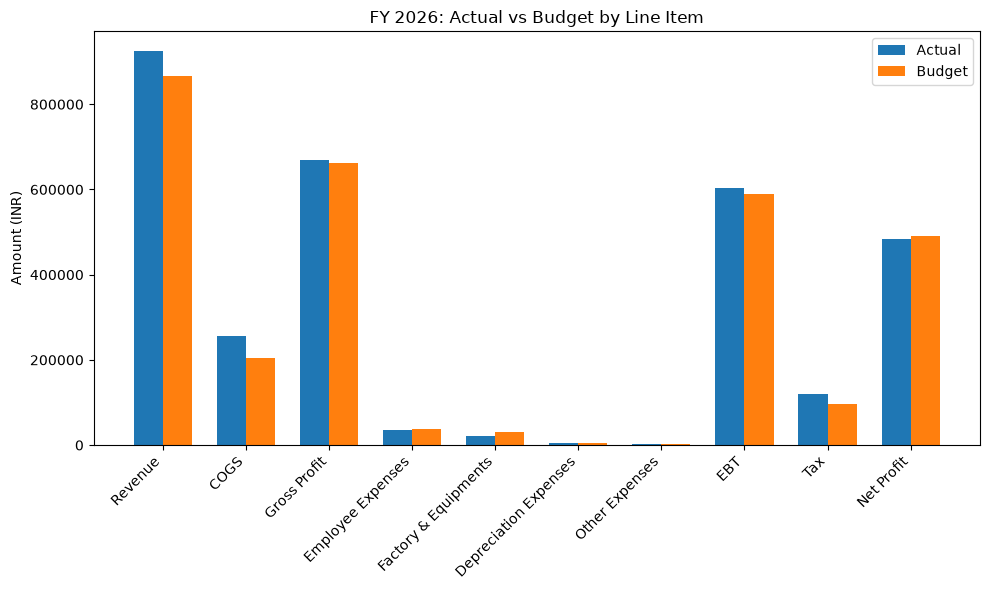

In [29]:
x = comparison["Particulars"]

plt.figure(figsize=(10, 6))
width = 0.35
positions = range(len(x))

plt.bar([p - width/2 for p in positions], comparison["FY_Total_Actual"], width, label="Actual")
plt.bar([p + width/2 for p in positions], comparison["FY_Total_Budget"], width, label="Budget")

plt.xticks(positions, x, rotation=45, ha="right")
plt.ylabel("Amount (INR)")
plt.title("FY 2026: Actual vs Budget by Line Item")
plt.legend()
plt.tight_layout()
plt.show()

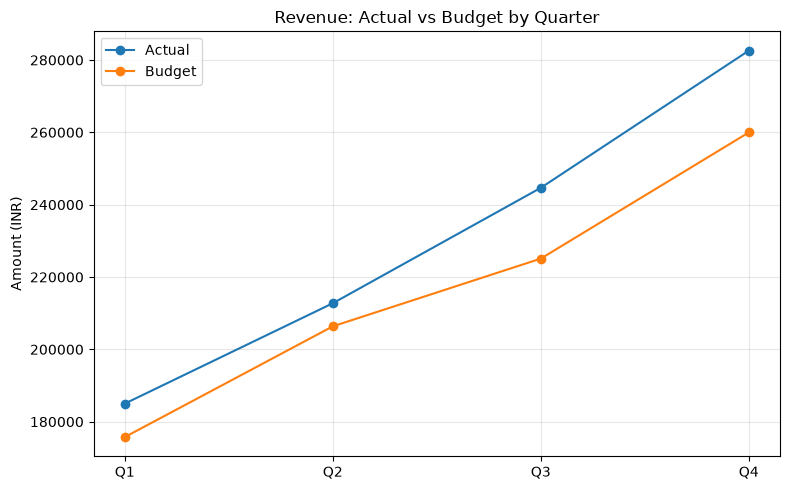

In [30]:
quarters = ["Q1", "Q2", "Q3", "Q4"]
rev_actual = comparison.loc[comparison["Particulars"] == "Revenue", [f"{q}_Actual" for q in quarters]].values.flatten()
rev_budget = comparison.loc[comparison["Particulars"] == "Revenue", [f"{q}_Budget" for q in quarters]].values.flatten()

plt.figure(figsize=(8, 5))
plt.plot(quarters, rev_actual, marker="o", label="Actual")
plt.plot(quarters, rev_budget, marker="o", label="Budget")
plt.title("Revenue: Actual vs Budget by Quarter")
plt.ylabel("Amount (INR)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()